# Word2Vec 단어 임베딩

BoW와 TF-IDF는 문서를 단어 빈도로 비교할 수 있지만 `king`과 `queen`처럼 서로 다른 단어가 의미상 가깝다는 관계는 표현하지 못한다.
**Word2Vec** 은 주변 문맥을 예측하는 과정에서 단어를 저차원 밀집 벡터로 학습하며, 비슷한 문맥에 나타나는 단어가 벡터 공간에서도 가까워지도록 만든다.
이렇게 얻은 벡터는 단어 유사도·검색 특성·신경망의 토큰 입력에 사용할 수 있다.

이 노트북에서는 작은 영어 코퍼스로 Skip-gram 모델을 학습하고, 어휘 행과 벡터의 대응 및 코사인 유사도를 확인한다. 이어서 학습된 40차원 벡터를 2차원으로 시각화하고, 한국어 NSMC 리뷰로 별도의 Word2Vec을 학습한다. 마지막에는 직접 학습한 모델과 GoogleNews 사전학습 벡터의 차이 및 선택 기준을 정리한다.


## 임베딩이란?

**임베딩(Embedding)** 은 단어처럼 서로 구분되는 대상을 일정한 길이의 실수 벡터로 바꾸는 표현 방법이다.
**단어 임베딩(Word Embedding)** 은 단어 하나를 벡터 하나에 대응시키며, 모델은 이 숫자 벡터를 입력으로 사용해 단어 사이의 관계를 계산한다.

원-핫 벡터는 단어마다 서로 다른 한 위치만 1로 표시하므로 단어를 구분할 수 있지만, `king`과 `queen`이 의미상 가깝다는 관계까지 표현하지 못한다. 단어 임베딩은 여러 실수 차원에 정보를 나누어 담고, 비슷한 문맥에서 사용된 단어가 벡터 공간에서도 가까워지도록 값을 학습한다.

```text
단어
  → 단어 ID
  → 임베딩 행렬에서 해당 ID의 행 선택
  → 고정 길이 단어 벡터

king → ID 7 → 임베딩 행렬의 7번 행 → 길이 40의 실수 벡터
```

**임베딩 행렬(Embedding Matrix)** 의 shape은 `(어휘 수, 임베딩 차원)`이다. 어휘가 25개이고 `vector_size=40`이면 행렬의 shape은 `(25, 40)`이며, 각 행은 등록 단어 하나의 40차원 벡터이다. 여기서 40개 차원은 사람이 미리 `성별`, `품사`, `감정`처럼 이름 붙인 특성이 아니라 학습 과정에서 여러 관계가 나뉘어 저장되는 잠재 차원이다.

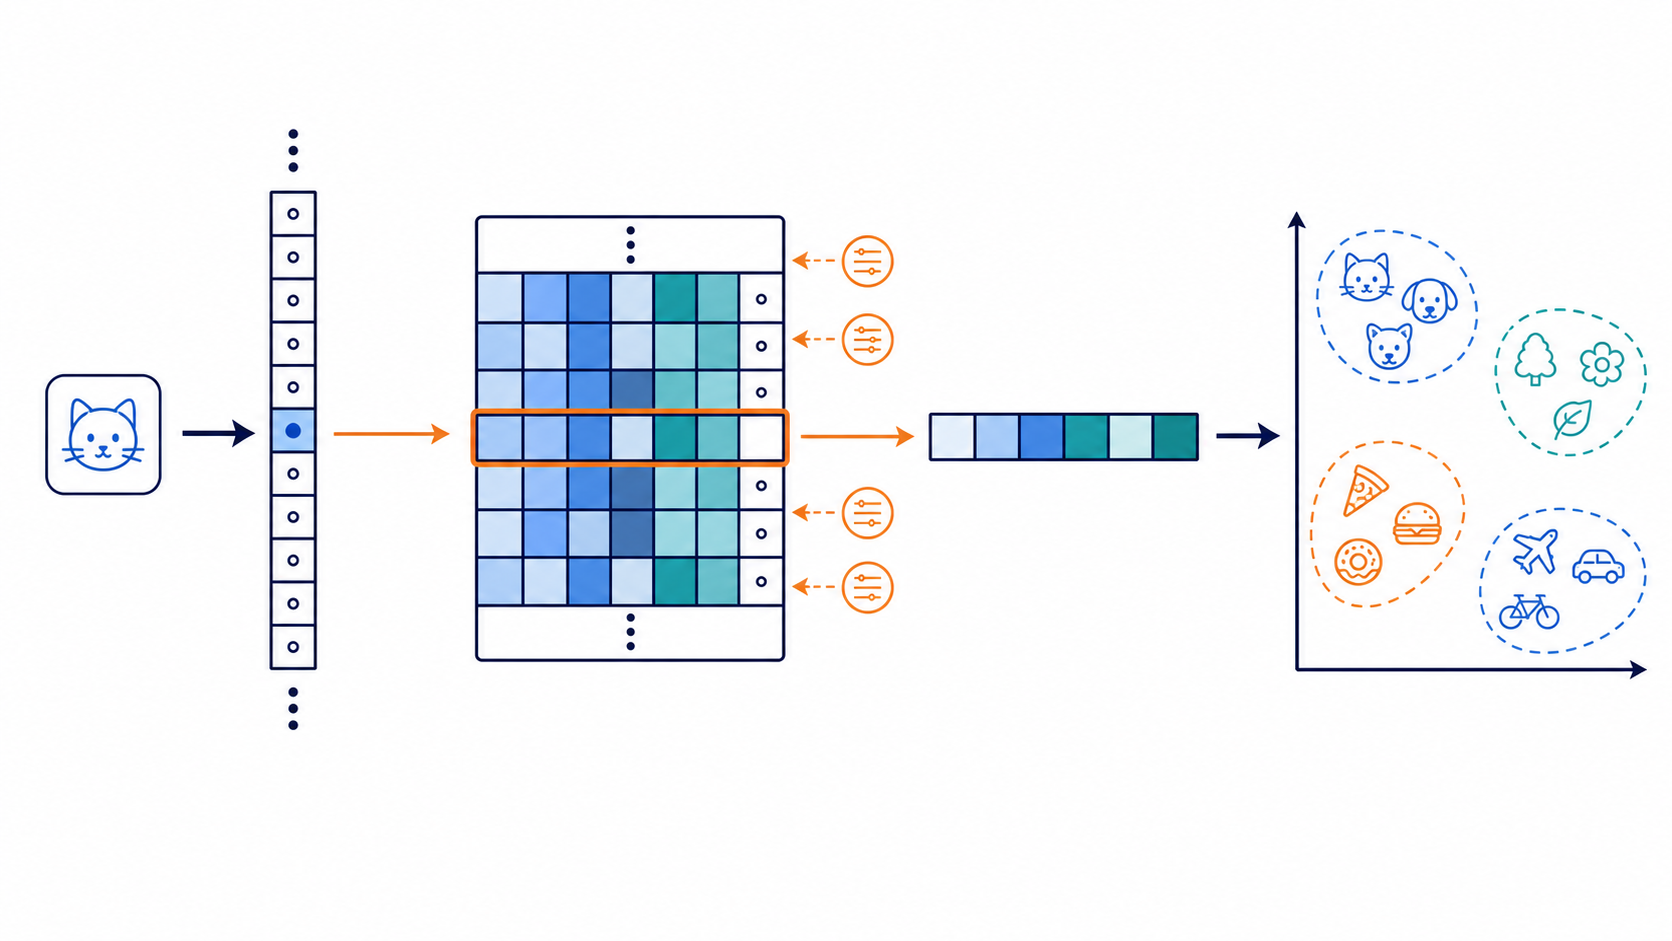

그림의 왼쪽은 단어 ID가 임베딩 행렬의 행 하나를 선택하는 과정이고, 가운데의 짧은 숫자 배열은 선택된 밀집 벡터이다. 오른쪽은 학습 목표에 따라 사용 맥락이 비슷한 단어 벡터들이 가까운 위치에 모일 수 있음을 나타낸다.

**Word2Vec** 은 임베딩 자체의 이름이 아니라 주변 단어 예측을 이용해 단어 임베딩 행렬의 값을 학습하는 방법이다. 학습이 끝나면 예측 모델의 가중치에서 단어 벡터를 꺼내 유사도 계산이나 다른 모델의 입력으로 사용한다. Word2Vec은 정적 임베딩이므로 같은 단어에는 문장과 관계없이 같은 벡터를 사용하며, 학습 어휘에 없는 단어는 직접 조회할 수 없다는 한계가 있다.

## 01. Word2Vec의 학습 원리

Word2Vec은 사람이 단어 쌍의 의미 점수를 직접 붙이지 않고 문장 안의 동시 등장 관계를 학습 신호로 사용한다.
**중심 단어(Center Word)** 는 현재 예측의 기준이고, **주변 단어(Context Word)** 는 중심 단어 앞뒤의 **문맥 창(Window)** 안에 들어오는 단어이다.
예를 들어 `king is a royal man`에서 `royal`을 중심으로 보고 `window=2`를 적용하면 가까운 `is`, `a`, `man`이 예측 관계를 만드는 주변 단어가 된다.

**CBOW(Continuous Bag of Words)** 는 여러 주변 단어를 입력해 중심 단어 하나를 예측하므로 비교적 빠르고 빈번한 단어의 안정적인 표현에 유리하다.
**Skip-gram** 은 중심 단어 하나로 여러 주변 단어를 예측해 학습 쌍이 더 많이 생기며, 작은 데이터나 드문 단어를 세밀하게 학습할 때 자주 사용한다. 두 방식 모두 전체 어휘를 매번 완전히 비교하는 비용을 줄이기 위해 실제 주변 단어와 소수의 무작위 비주변 단어를 구분하는 **Negative Sampling** 을 사용할 수 있다.

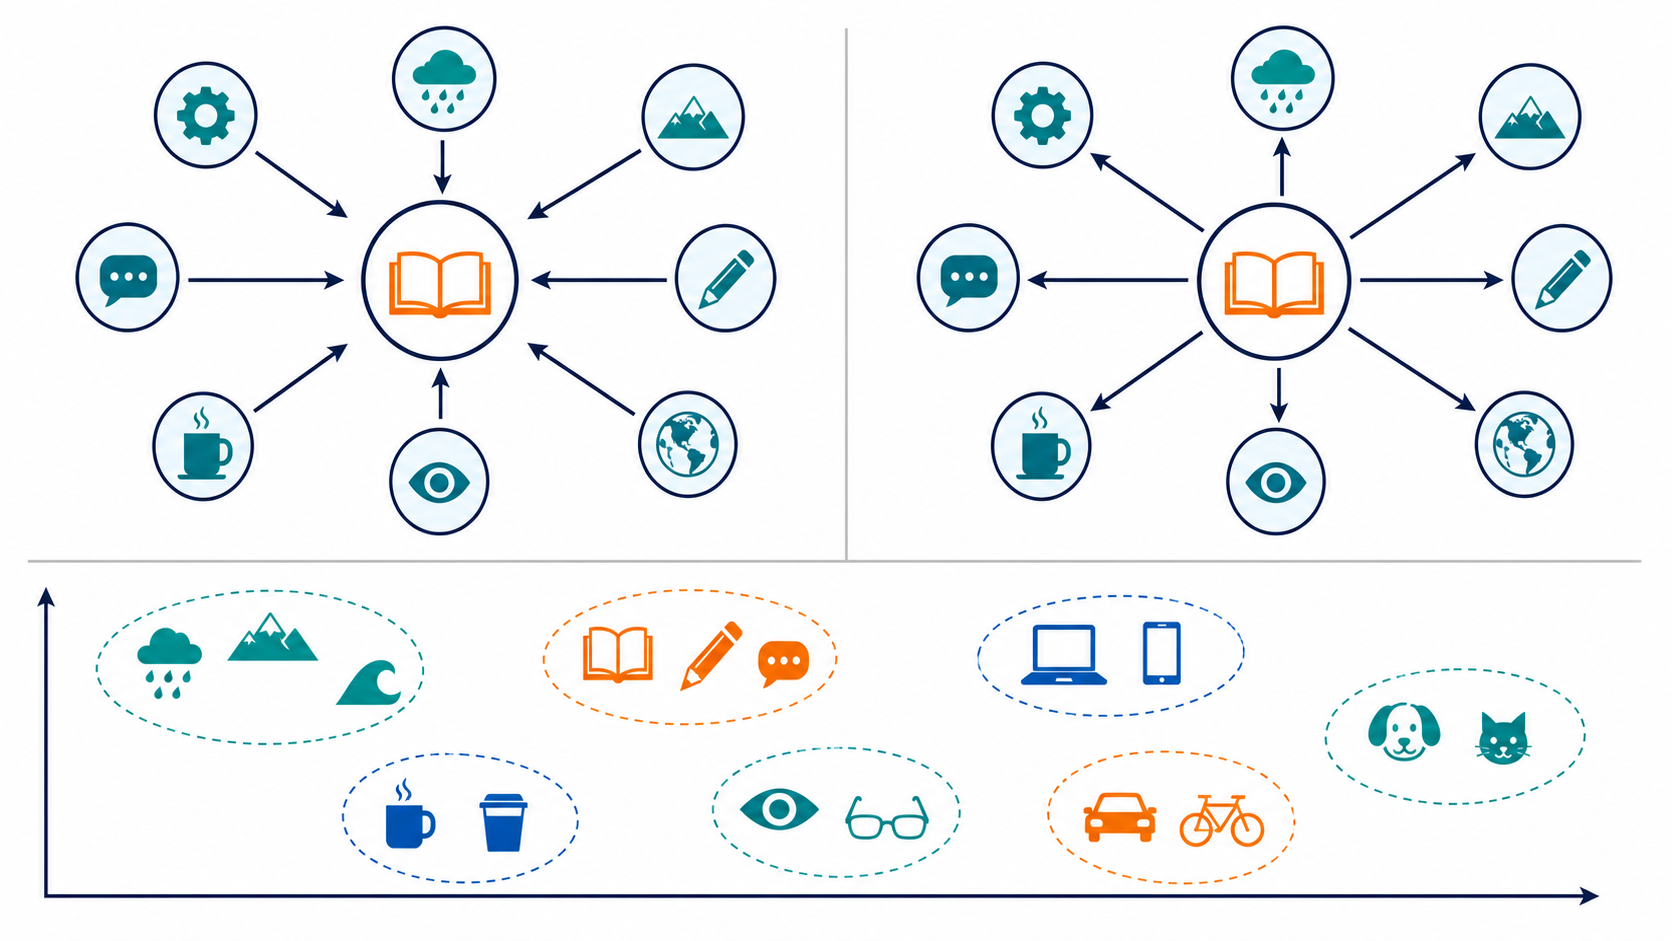

위 그림의 왼쪽은 여러 주변 단어로 중심 단어를 예측하는 CBOW이고, 오른쪽은 중심 단어에서 주변 단어마다 별도의 학습 쌍을 만드는 Skip-gram이다. 그림은 원리를 보여 주기 위해 `window=2`를 사용하며 아래 실습 코드는 `window=3`을 사용한다.

이번 코드의 `sg=1`은 Skip-gram을 선택하고 `window=3`은 중심 단어 앞뒤 최대 세 토큰을 문맥으로 사용한다. 학습이 끝나면 예측용 얕은 신경망의 가중치가 단어 임베딩 행렬로 남지만, CBOW와 Skip-gram 중 어느 쪽이 더 좋은지는 이름이 아니라 코퍼스 크기와 실제 작업 성능으로 판단한다.

## 02. 실습 환경 준비

`gensim`은 Word2Vec과 FastText를 포함한 벡터 모델 라이브러리이다. 한국어 예제에서는 데이터 처리를 위한 `pandas`, 형태소 분석을 위한 `KoNLPy`의 `Okt`, 진행 상황을 표시하는 `tqdm`을 사용한다. 벡터 시각화에는 `matplotlib`과 `scikit-learn`의 PCA를 사용한다.

`%pip`은 터미널의 다른 Python이 아니라 현재 노트북 커널이 사용하는 환경에 패키지를 설치한다. `Okt`는 내부적으로 JVM을 사용하므로 Python 패키지와 별도로 Java가 설치되어 있어야 한다.

In [2]:
%pip install -q gensim pandas konlpy tqdm matplotlib scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 03. 문장별 토큰 코퍼스 준비

gensim Word2Vec의 `sentences`에는 하나의 긴 문자열이 아니라 `문장별 토큰 목록`을 전달한다. 바깥 리스트의 원소 하나가 문장이고 안쪽 리스트는 그 문장의 토큰 순서를 보존하므로, 모델은 각 토큰 주변에서 중심-주변 학습 쌍을 만들 수 있다. 이 실습은 Word2Vec 학습에 집중하기 위해 토큰화가 끝난 짧은 문장을 직접 준비한다.

기본 문장을 여러 번 반복하는 이유는 작은 예제에서도 같은 문맥 관계를 여러 차례 관찰하게 하기 위해서이다. 실행 후 기본 문장 수 `10`, 학습 문장 수 `1000`, 첫 문장 토큰 목록이 출력되는지 확인하면 입력의 중첩 구조와 반복량을 읽을 수 있다. 실제 데이터에서는 인위적으로 반복하기보다 충분한 규모의 자연스러운 코퍼스를 사용한다.

In [1]:
base_sentences = [
    ["king", "is", "a", "royal", "man"],
    ["queen", "is", "a", "royal", "woman"],
    ["king", "and", "queen", "rule", "the", "kingdom"],
    ["prince", "is", "a", "young", "royal", "man"],
    ["princess", "is", "a", "young", "royal", "woman"],
    ["man", "and", "woman", "are", "people"],
    ["boy", "is", "a", "young", "man"],
    ["girl", "is", "a", "young", "woman"],
    ["dog", "and", "cat", "are", "animals"],
    ["apple", "and", "banana", "are", "fruit"],
]

training_sentences = base_sentences * 100

print("기본 문장 수:", len(base_sentences))
print("학습 문장 수:", len(training_sentences))
print("첫 문장:", training_sentences[0])


기본 문장 수: 10
학습 문장 수: 1000
첫 문장: ['king', 'is', 'a', 'royal', 'man']


## 04. Skip-gram Word2Vec 학습

`Word2Vec`은 문장별 토큰 목록을 읽어 어휘 사전을 만든 뒤 중심-주변 예측을 반복하며 임베딩 행렬을 학습한다.
`vector_size=40`은 단어 하나를 나타내는 실수 특성의 수이고,
`window=3`은 중심 단어 앞뒤에서 문맥으로 볼 최대 범위이다.
`min_count=1`은 한 번 이상 등장한 모든 단어를 어휘에 남기고,
`sg=1`은 CBOW가 아닌 Skip-gram을 선택한다.

`negative=5`는 실제 주변 단어마다 무작위 비주변 단어 다섯 개를 비교하고,
`epochs=150`은 준비한 코퍼스를 150회 반복 학습한다.
`workers=1`과 `seed=42`는 병렬 학습의 비결정성을 줄여 수업 환경의 실행 차이를 완화한다.

다음 모델 정보에서 어휘가 비어 있지 않고 벡터 차원이 40으로 표시되면 학습 결과를 조회할 준비가 된 것이다. 다만 모델이 성공적으로 만들어졌더라도 이 작은 코퍼스가 일반 영어의 의미 관계를 충분히 학습했다고 볼 수 없다.

In [5]:
from gensim.models import Word2Vec
# Word2Vec 모델 생성 시 위에 준비한 문장을 전달하면
# 자동으로 언어,어휘 사전이 구축과 학습이 수행된다
word2vec_model = Word2Vec(
    sentences=training_sentences,
    vector_size=40, #단어 1개는 실수형 feature 40개로 변환 ( == 40차원)
    window=3, # 중신 단어 앞뒤 문맥창(예측 관계 범위)
    min_count=1, # 1번이라도 등장하는 단어를 어휘에 등록
    sg=1, # skip-gram 방식 선택 (중심어 하나를 선택하겠다)
    negative=5, # 중심단어가 있고 주변 단어가 있을때 , 실제 주변 당어마다 무작위 비주변 단어를 비교
    epochs=150, # 150회 돈다
    workers=1, # 병렬 처리 코어 개수 설정(1은 병렬하지 않는다)
    seed=42, # random seed처럼 계속 랜덤되지 않게 고정한다
)

## 05. 어휘와 임베딩 행렬 읽기

`model.wv`는 학습된 단어와 벡터를 조회하는 `KeyedVectors` 객체이다. `key_to_index`는 단어를 임베딩 행 번호에 연결하고, `vectors`의 같은 행에는 그 단어의 벡터가 저장된다. 따라서 `vectors`의 shape은 `(어휘 수, vector_size)`이고 `get_vector("king")`은 해당 행의 길이 40인 벡터 하나를 반환한다.

**OOV(Out Of Vocabulary)** 는 학습 어휘에 등록되지 않은 단어이다. Word2Vec은 단어 전체를 어휘 단위로 사용하므로 등록된 `king`은 조회할 수 있지만 코퍼스에 없던 `kings`의 벡터는 직접 만들지 못한다. 실행 후 임베딩 행렬의 두 번째 축과 `king` 벡터 길이가 모두 40이고 등록 여부가 각각 `True`, `False`인지 확인하면 단어-행-벡터 대응과 고정 어휘의 한계를 함께 읽을 수 있다.

In [6]:
vocabulary = list(word2vec_model.wv.key_to_index)
king_vector = word2vec_model.wv.get_vector("king")

print("임베딩 행렬 shape:", word2vec_model.wv.vectors.shape)
print("어휘 수:", len(vocabulary))
print("어휘 목록:", vocabulary)
print("king 벡터 shape:", king_vector.shape)
print("king 등록 여부:", "king" in word2vec_model.wv)
print("kings 등록 여부:", "kings" in word2vec_model.wv)


임베딩 행렬 shape: (24, 40)
어휘 수: 24
어휘 목록: ['a', 'is', 'young', 'and', 'woman', 'man', 'royal', 'are', 'queen', 'king', 'fruit', 'banana', 'apple', 'animals', 'cat', 'dog', 'girl', 'boy', 'people', 'princess', 'prince', 'kingdom', 'the', 'rule']
king 벡터 shape: (40,)
king 등록 여부: True
kings 등록 여부: False


In [7]:
import sys
print(sys.executable)

/Users/choejiheum/SKN_AI/08_nlp/.venv/bin/python


## 06. 코사인 유사도와 가까운 단어

단어 임베딩의 코사인 유사도는 두 벡터의 방향이 얼마나 가까운지 나타낸다. `similarity()`는 지정한 두 단어를 비교하고 `most_similar()`는 기준 단어와 가까운 등록 단어를 찾는다.

유사도는 이 코퍼스에서 비슷한 문맥에 나타났다는 증거이다. 실행 후 `king-queen` 점수를 `king-apple`과 비교하고 `queen`의 가까운 이웃 다섯 개가 왕실 문맥을 공유하는지 살펴본다. 전자의 점수가 더 높으면 의도한 문맥 관계가 일부 반영됐다고 볼 수 있지만, 동의어·상하 관계 또는 사실의 정확성이 자동으로 보장되는 것은 아니다. 작은 코퍼스에서는 예상 밖 단어가 가까이 나올 수 있으므로 점수 하나를 고정된 정답으로 해석하지 않는다.

In [9]:
sim1 = word2vec_model.wv.similarity("king", "queen")
print("king-queen: ", round(float(sim1), 4))

sim2 = word2vec_model.wv.similarity("king", "apple")
print("king-apple: ", round(float(sim2), 4))

print("king과 가까운 단어 : ", word2vec_model.wv.most_similar("king", topn=5))
print("queen과 가까운 단어 : ", word2vec_model.wv.most_similar("queen", topn=5))

king-queen:  0.6393
king-apple:  0.1768
king과 가까운 단어 :  [('prince', 0.6408989429473877), ('queen', 0.6393125057220459), ('kingdom', 0.6216768622398376), ('the', 0.6094557046890259), ('rule', 0.5889487862586975)]
queen과 가까운 단어 :  [('princess', 0.664576530456543), ('king', 0.6393125057220459), ('kingdom', 0.6240168213844299), ('the', 0.6084754467010498), ('rule', 0.6022778153419495)]


## 07. 학습된 임베딩 벡터 시각화

단어 하나의 임베딩은 40개 숫자로 이루어져 있어 화면에 그대로 그릴 수 없다. **PCA(주성분 분석)** 는 고차원 데이터의 변화가 큰 방향을 찾아 2차원처럼 더 낮은 차원으로 투영하는 방법이다. 여기서는 학습된 단어 12개의 40차원 벡터를 2차원 좌표로 줄여 단어 간 배치를 살펴본다.

시각화에서 가까운 단어는 원래 벡터 공간에서도 비슷한 문맥을 학습했을 가능성이 있다. 그러나 두 축은 `성별`, `왕족`처럼 사람이 이름 붙인 의미 축이 아니며, 40차원을 2차원으로 줄이는 과정에서 거리와 방향이 일부 왜곡된다. 저장된 출력의 설명 분산 비율 `0.4908`은 두 축이 12개 정규화 벡터의 변동 중 약 49.08%만 담았다는 뜻이다. 따라서 그래프는 관계를 탐색하는 보조 자료이며 의미 유사도의 최종 증거로 단정할 수 없다.

시각화 입력 shape: (12, 40)
2차원 좌표 shape: (12, 2)
두 축의 설명 분산 비율 합: 0.4908


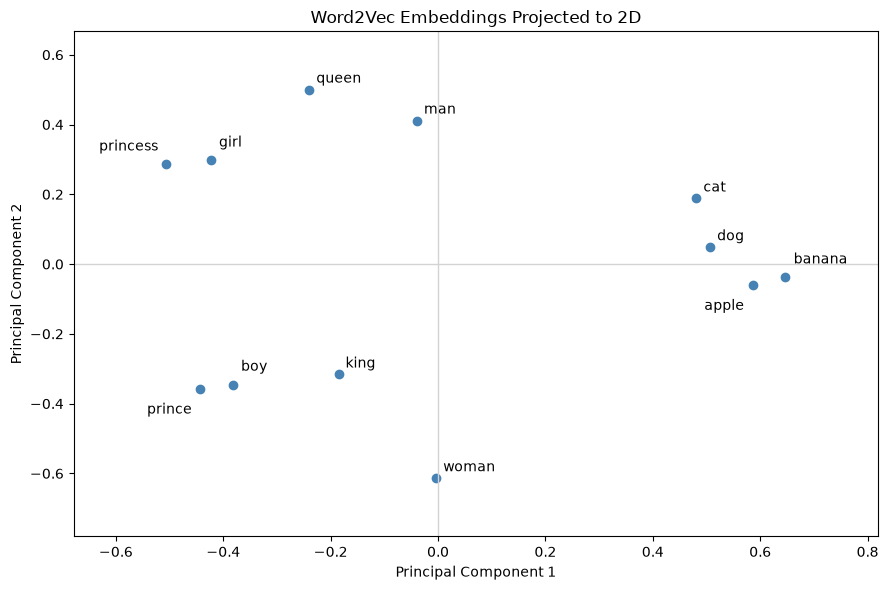

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

visual_words = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "dog", "cat", "apple", "banana",
]

visual_vectors = np.vstack([
    word2vec_model.wv.get_vector(word, norm=True)
    for word in visual_words
])

pca = PCA(n_components=2)
coordinates_2d = pca.fit_transform(visual_vectors)

print("시각화 입력 shape:", visual_vectors.shape)
print("2차원 좌표 shape:", coordinates_2d.shape)
print("두 축의 설명 분산 비율 합:", round(float(pca.explained_variance_ratio_.sum()), 4))

figure, axis = plt.subplots(figsize=(9, 6))
axis.scatter(coordinates_2d[:, 0], coordinates_2d[:, 1], color="steelblue")
right_aligned_words = {"princess", "prince", "apple"}
label_offsets = {
    "princess": (-6, 10),
    "girl": (6, 10),
    "prince": (-6, -18),
    "boy": (6, 10),
    "apple": (-6, -18),
    "banana": (6, 10),
}
for word, (x_coordinate, y_coordinate) in zip(visual_words, coordinates_2d):
    horizontal_alignment = "right" if word in right_aligned_words else "left"
    label_offset = label_offsets.get(word, (5, 5))
    axis.annotate(
        word,
        (x_coordinate, y_coordinate),
        xytext=label_offset,
        textcoords="offset points",
        ha=horizontal_alignment,
    )

axis.axhline(0, color="lightgray", linewidth=1)
axis.axvline(0, color="lightgray", linewidth=1)
axis.set_title("Word2Vec Embeddings Projected to 2D")
axis.set_xlabel("Principal Component 1")
axis.set_ylabel("Principal Component 2")
axis.margins(0.15)
figure.tight_layout()
plt.show()


## 08. 모델 저장과 복원

`save()`는 어휘, 벡터와 학습 설정을 포함한 전체 Word2Vec 모델을 저장한다. `Word2Vec.load()`로 복원하면 벡터 조회뿐 아니라 동일한 구조에서 추가 학습도 이어갈 수 있다. 다음 코드에서 복원한 임베딩 행렬 shape이 원본과 같고 `queen` 벡터 비교가 `True`이면 저장 과정이 벡터 값을 보존했다는 뜻이다.

조회용 벡터만 다른 도구와 교환하려면 `model.wv.save_word2vec_format()`을 사용한다. 전체 모델 저장과 벡터 전용 저장은 목적이 다르다.

In [11]:
model_path = 'word2vec_model.model'
word2vec_model.save(model_path)

## 09. 한국어 Word2Vec: NSMC

Word2Vec의 학습 원리는 언어와 관계없이 같지만, 무엇을 단어 하나로 볼지는 토큰화 방식에 따라 달라진다. 한국어는 조사와 어미가 결합하므로 문장을 공백만으로 나누기보다 형태소 분석 결과를 Word2Vec의 입력으로 사용하는 경우가 많다.

- **NSMC(Naver Sentiment Movie Corpus)**: 네이버 영화 리뷰 문장과 긍정·부정 레이블을 모은 한국어 데이터셋
- **`Okt`**: 한국어 문장을 형태소 단위로 나누고 정규화·어간 처리를 지원하는 KoNLPy 분석기
- **`stem=True`**: `재밌었다`, `재미있었다`처럼 활용된 표현을 가능한 기본형에 가깝게 통일하는 설정

NSMC에는 긍정·부정 레이블도 있지만 Word2Vec은 정답 레이블이 아니라 문장 안의 주변 문맥으로 단어 벡터를 학습하므로 이 코드에서는 `document` 열만 사용한다.

원본 노트북은 NSMC 20만 건 전체를 처리하지만 형태소 분석에 시간이 오래 걸린다. 컴팩트 버전은 학습 흐름과 결과 해석을 유지하면서 앞부분 2만 건만 사용한다. 표본을 줄이면 실행 시간은 짧아지지만 학습 어휘와 유사 단어의 품질도 달라질 수 있다.

In [13]:
from pprint import pprint
import pandas as pd
from konlpy.tag import Okt
from tqdm import tqdm

nsmc_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt"

# NSMC 원본에서 2만줄만 읽기
korean_reviews_df = pd.read_table(nsmc_url, nrows=20_000)

korean_reviews = (
    korean_reviews_df["document"]
    .dropna() # 결측치 제거
    .astype(str) # 스트링 형변환 
    .str.replace(r"[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", " ", regex=True) # 한글제외한 나머지 빈칸변경 정규표현식
    .str.replace(r"\s+", " ", regex=True) # 연속되는 빈칸을 하나로 만드는 정규표현식
    .str.strip() # 문자열 좌우 공백 제거
)

# 정제된 데이터가 ""(빈칸)인 경우를 제외한 리뷰만 남기기
korean_reviews = korean_reviews[korean_reviews.ne("")]

korean_stopwords = {
    "의", "가", "이", "은", "들", "는", "좀", "잘", "걍",
    "과", "도", "를", "으로", "자", "에", "와", "한", "하다",
}

# Okt는 한국어를 형태고 시간으로 토큰화 시킨다 
# ex)
# 형태소는 뜻을 가진 가장 작은 언어 단위예요.
# 예를 들어:
# "나는 학교에 갔다"
# 를 형태소로 나누면 대략 이렇게 됩니다.
# 나 / 는 / 학교 / 에 / 갔 / 다
okt = Okt()
korean_sentences = []

# 리뷰마다 형태소를 기본형에 가깝게 분석하고 
# 한 글자 토큰 & 불용어 제거 수행
for review in tqdm(korean_reviews, desc="한국어 형태소 분석"):
    morphs = okt.morphs(review, stem=True)
    content_tokens = [
        token
        for token in morphs
        if len(token) > 1 and token not in korean_stopwords
    ]

    if content_tokens:
        korean_sentences.append(content_tokens)

print("읽은 리뷰 수:", len(korean_reviews_df))
print("정제 후 리뷰 수:", len(korean_reviews))
print("학습 문장 수:", len(korean_sentences))
print("첫 형태소 문장:", korean_sentences[0])


한국어 형태소 분석: 100%|██████████| 19834/19834 [00:49<00:00, 402.22it/s]

읽은 리뷰 수: 20000
정제 후 리뷰 수: 19834
학습 문장 수: 19680
첫 형태소 문장: ['어리다', '보고', '지금', '다시', '보다', '재밌다', 'ㅋㅋ']


### 한국어 임베딩 학습과 유사 단어

한국어 모델도 영어 모델과 같은 `Word2Vec` 클래스로 학습한다. `vector_size=50`이므로 등록 단어마다 길이 50의 벡터가 생기며, `min_count=3`은 표본에서 세 번 미만 등장한 형태소를 어휘에서 제외한다. `연기`와 `배우`의 가까운 단어를 조회하면 한국어 영화 리뷰에서 공유한 문맥이 벡터에 어떻게 반영됐는지 확인할 수 있다.

유사 단어는 일반적인 국어사전 관계가 아니라 NSMC 표본의 문맥 관계이다. 표본 범위, 형태소 분석 결과와 학습 환경에 따라 단어의 순서와 점수가 달라질 수 있다.

In [17]:
from pprint import pprint
# 한국어 토큰화 문장들을 사용해 Word2Vec 모델을 학습한다.
korean_word2vec_model = Word2Vec(
    sentences=korean_sentences,  # 형태소 단위로 토큰화된 문장들의 리스트
    vector_size=50,              # 단어 하나를 50차원 실수 벡터로 표현
    window=5,                    # 중심 단어 기준 앞뒤 5개 단어까지 문맥으로 고려
    min_count=3,                 # 전체 코퍼스에서 3회 이상 등장한 단어만 학습 대상에 포함
    sg=1,                        # Skip-gram 방식: 중심 단어로 주변 단어를 예측
    negative=5,                  # 실제 주변 단어와 비교할 음성 샘플 단어 수
    epochs=20,                   # 전체 학습 데이터를 20회 반복 학습
    workers=1,                   # 병렬 처리에 사용할 CPU 코어 수
    seed=42,                     # 실행할 때마다 비슷한 결과를 얻기 위한 난수 시드
)

# 학습된 단어 수 × 각 단어의 벡터 차원(50)을 확인한다.
print("한국어 임베딩 행렬 shape:", korean_word2vec_model.wv.vectors.shape)

# 지정한 단어와 벡터 공간에서 가까운 단어 5개를 출력한다.
for query_word in ["연기", "배우"]:
    similar_words = korean_word2vec_model.wv.most_similar(query_word, topn=5)
    print(f"{query_word}의 가까운 단어:", similar_words)

한국어 임베딩 행렬 shape: (5397, 50)
연기의 가까운 단어: [('연기력', 0.7855921983718872), ('안성기', 0.6727540493011475), ('퍼스', 0.6615433096885681), ('엄지원', 0.6591322422027588), ('양자경', 0.6579627394676208)]
배우의 가까운 단어: [('연기자', 0.6736971735954285), ('신인', 0.6666041612625122), ('일품', 0.6617348194122314), ('김민희', 0.6544766426086426), ('스텝', 0.654340386390686)]


## 10. 사전학습된 Word2Vec

**사전학습된 임베딩(Pre-trained Embedding)** 은 다른 사람이 대규모 코퍼스로 미리 학습해 공개한 단어 벡터이다. 직접 학습은 현재 데이터에 맞는 어휘와 문맥을 배울 수 있지만 충분한 데이터와 학습 시간이 필요하다. 사전학습 벡터는 바로 조회할 수 있는 대신 학습 언어·도메인·어휘가 현재 작업과 맞지 않을 수 있다.

원본에서 사용하는 `word2vec-google-news-300`은 Google News 문서로 학습된 영어 Word2Vec이다. 약 300만 개 어휘를 각각 300차원 벡터로 표현한다. 다음 셀은 전체 벡터를 내려받지 않고 Gensim 카탈로그의 모델 규모만 확인한다.

In [20]:
import gensim.downloader as api

google_news_info = api.info("word2vec-google-news-300")

vocabulary_size = google_news_info["num_records"]
vector_dimension = google_news_info["parameters"]["dimension"]
download_size_gib = google_news_info["file_size"] / (1024 ** 3)

print("모델 이름: word2vec-google-news-300")
print(f"어휘 수: {vocabulary_size:,}")
print("벡터 차원:", vector_dimension)
print(f"다운로드 크기: {download_size_gib:.2f} GiB")

모델 이름: word2vec-google-news-300
어휘 수: 3,000,000
벡터 차원: 300
다운로드 크기: 1.62 GiB


### 사전학습 벡터를 불러오는 방법

`KeyedVectors`는 학습 신경망 전체가 아니라 `단어 → 벡터` 조회에 필요한 어휘와 임베딩만 보관하는 객체이다. GoogleNews 파일을 미리 내려받았다면 다음 코드로 불러와 `most_similar()`와 `similarity()`를 사용할 수 있다.

```python
from gensim.models import KeyedVectors

google_news_vectors = KeyedVectors.load_word2vec_format(
    "GoogleNews-vectors-negative300.bin.gz",
    binary=True,
    limit=200_000,
)

print(google_news_vectors.most_similar("king", topn=5))
print(google_news_vectors.similarity("king", "queen"))
```

- **`binary=True`**: GoogleNews 파일이 텍스트가 아닌 Word2Vec 바이너리 형식임을 지정하는 값
- **`limit=200_000`**: 파일의 앞쪽 어휘 20만 개만 메모리에 올리는 설정

`limit`은 메모리에 올리는 어휘 수만 줄이며 원본 파일의 약 1.62GiB 다운로드 자체를 줄이지 않는다. 또한 이 모델은 영어 뉴스 문맥으로 학습됐으므로 한국어 단어를 조회할 수 없고, 전문 분야나 최신 표현에서는 OOV 또는 부적절한 유사도가 나타날 수 있다. 이러한 비용과 도메인 차이 때문에 컴팩트 수업에서는 전체 다운로드를 실행하지 않는다.

In [ ]:
from gensim.models import KeyedVectors

google_news_vectors = KeyedVectors.load_word2vec_format(
  "GoogleNews-vectors-negative300.bin.gz",
  binary=True,
  limit=200_000,
)

print(google_news_vectors.most_similar("king", topn=5))
print(google_news_vectors.similarity("king", "queen"))

## 11. 직접 학습과 사전학습 벡터의 선택 기준

현재 데이터의 언어와 전문 용어가 중요하고 충분한 문서가 있다면 Word2Vec을 직접 학습할 수 있다. 영어 TED 문장이나 한국어 NSMC 리뷰처럼 목표 도메인의 문맥을 반영할 수 있지만, 토큰화 규칙·어휘 빈도·학습 시간과 품질을 직접 관리해야 한다. 이 노트북의 한국어 2만 건 결과는 흐름 확인용이며 더 안정적인 임베딩이 필요하면 전체 데이터와 별도 검증을 사용한다.

대규모 범용 벡터를 빠르게 활용하려면 사전학습 모델을 선택할 수 있다. 학습 비용은 줄지만 파일 크기와 메모리, 라이선스, 언어·도메인 적합성 및 OOV를 확인해야 한다. GoogleNews 벡터가 크다는 사실만으로 한국어 영화 리뷰나 현재 업무 데이터에 더 적합하다고 볼 수 없다.

PCA 산점도와 코사인 유사도는 임베딩이 학습한 관계를 살펴보는 도구이다. 2차원 배치는 고차원 구조를 일부 잃고, 가까운 벡터도 사실 관계나 사전적 동의어를 보장하지 않으므로 실제 작업 성능과 함께 평가한다.

Word2Vec은 한 단어에 하나의 고정 벡터를 부여하므로 문맥에 따라 의미가 달라지는 다의어를 구분하지 못한다. 다음 단원에서는 임베딩 행렬을 신경망 입력으로 연결하고, FastText에서는 문자 n-gram으로 OOV 문제를 완화한다.